# Random Forest Classifier

In [1]:
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [2]:
data = pd.read_csv("/content/drive/MyDrive/InterIIT_2023-24/btcusdt_1h.csv")
data.head()

,datetime,open,high,low,close,volume
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329


In [3]:
data.tail()


,datetime,open,high,low,close,volume
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.60178
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.10380
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.85993
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.14201
35207,2022-01-12 05:30:00,42729.29,42965.00,42578.02,42675.00,1004.90689


In [4]:
# Features construction
data['Open-Close'] = (data.open - data.close)/data.open
data['High-Low'] = (data.high - data.low)/data.low
data['percent_change'] = data['close'].pct_change()
data['std_5'] = data['percent_change'].rolling(5).std()
data['ret_5'] = data['percent_change'].rolling(5).mean()
data.dropna(inplace=True)

# X is the input variable
X = data[['Open-Close', 'High-Low', 'std_5', 'ret_5']]

# Y is the target or output variable
y = np.where(data['close'].shift(-1) > data['close'], 1, -1)

In [5]:
# Total dataset length
dataset_length = data.shape[0]

# Training dataset length
split = int(dataset_length * 0.75)
split

26402

In [6]:
# Splitiing the X and y into train and test datasets
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Print the size of the train and test dataset
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(26402, 4) (8801, 4)
(26402,) (8801,)


In [7]:
# Create the model on train dataset
clf = RandomForestClassifier()  # Create a RandomForestClassifier instance

model = clf.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
print('Correct Prediction (%): ', accuracy_score(y_test, model.predict(X_test), normalize=True)*100.0)

# Run the code to view the classification report metrics
from sklearn.metrics import classification_report
report = classification_report(y_test, model.predict(X_test))
print(report)

Correct Prediction (%):  51.74411998636519
              precision    recall  f1-score   support

          -1       0.52      0.49      0.50      4377
           1       0.52      0.55      0.53      4424

    accuracy                           0.52      8801
   macro avg       0.52      0.52      0.52      8801
weighted avg       0.52      0.52      0.52      8801



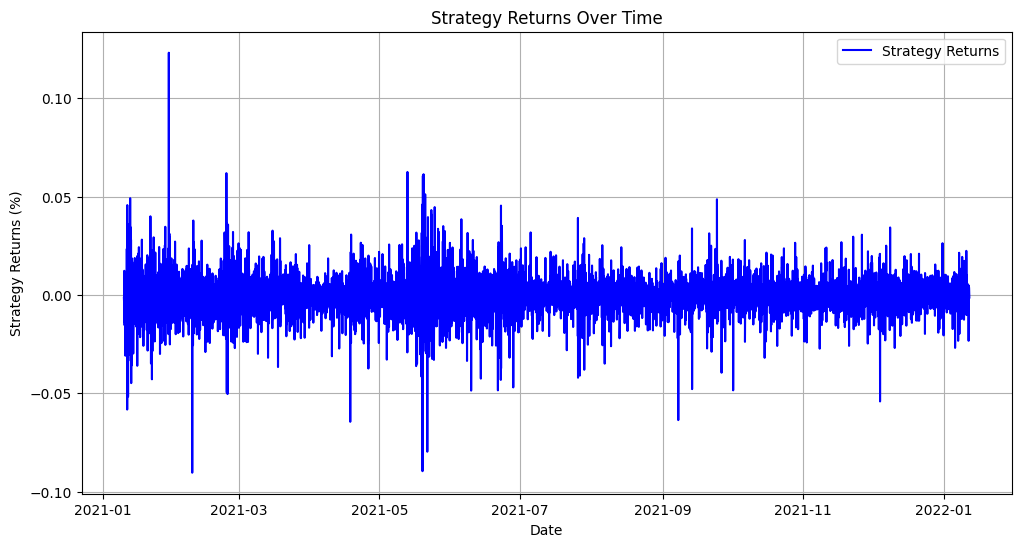

In [8]:
# Plot strategy returns along with the date on the x-axis
data['Date'] = pd.to_datetime(data['datetime'])  # Convert the 'Date' column to datetime
data['strategy_returns'] = data.percent_change.shift(-1) * model.predict(X)
plt.figure(figsize=(12, 6))  # Set the figure size
plt.plot(data['Date'][split:], data['strategy_returns'][split:], label='Strategy Returns', color='blue')
plt.xlabel('Date')
plt.ylabel('Strategy Returns (%)')
plt.title('Strategy Returns Over Time')
plt.legend()
plt.grid(True)
plt.show()


## Integrated SMA with Random Forest

(26402, 4) (8801, 4)
(26402,) (8801,)
Correct Prediction (%):  51.5282354277923
              precision    recall  f1-score   support

          -1       0.51      0.48      0.49      4377
           1       0.52      0.55      0.53      4424

    accuracy                           0.52      8801
   macro avg       0.52      0.52      0.51      8801
weighted avg       0.52      0.52      0.51      8801

First 20 Combined Signals: [0, -1, -1, 0, -1, -1, -1, -1, 0, 0, -1, 0, 0, 0, 0, 0, -1, -1, 0, 0]


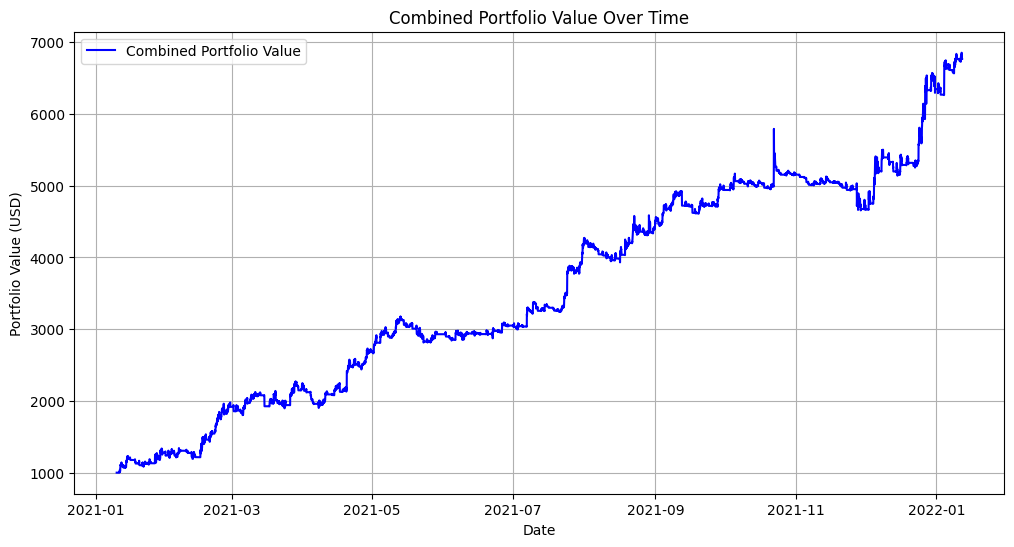

Final Combined Portfolio Value: $6771.19
Maximum Drawdown: -19.62%
Sharpe Ratio: -2.9836
Sortino Ratio: -3.5923


In [9]:
# Random Forest Classifier
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

data = pd.read_csv("/content/drive/MyDrive/InterIIT_2023-24/btcusdt_1h.csv")
data.head()

data.tail()

# Features construction
data['Open-Close'] = (data.open - data.close) / data.open
data['High-Low'] = (data.high - data.low) / data.low
data['percent_change'] = data['close'].pct_change()
data['std_5'] = data['percent_change'].rolling(5).std()
data['ret_5'] = data['percent_change'].rolling(5).mean()
data.dropna(inplace=True)

# X is the input variable
X = data[['Open-Close', 'High-Low', 'std_5', 'ret_5']]

# Y is the target or output variable
y = np.where(data['close'].shift(-1) > data['close'], 1, -1)

# Total dataset length
dataset_length = data.shape[0]

# Training dataset length
split = int(dataset_length * 0.75)
split

# Splitting the X and y into train and test datasets
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Print the size of the train and test dataset
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

# Create the model on train dataset
clf = RandomForestClassifier()  # Create a RandomForestClassifier instance

model = clf.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
print('Correct Prediction (%): ', accuracy_score(y_test, model.predict(X_test), normalize=True) * 100.0)

# Run the code to view the classification report metrics
from sklearn.metrics import classification_report
report = classification_report(y_test, model.predict(X_test))
print(report)

# Apply the strategy logic - Hold stock between -0.25% and 0.25%
data['Date'] = pd.to_datetime(data['datetime'])  # Convert the 'Date' column to datetime
data['strategy_returns'] = data.percent_change.shift(-1) * model.predict(X)

# Define the threshold values
lower_threshold = -0.001  # -0.25% as decimal
upper_threshold = 0.001   # 0.25% as decimal

# Apply the strategy logic
data['strategy_returns'] = np.where(
    (data['strategy_returns'] >= lower_threshold) & (data['strategy_returns'] <= upper_threshold),
    0,  # Hold stock
    data['strategy_returns']  # Proceed as usual
)

# Portfolio simulation
starting_capital = 1000  # Starting capital in USD
portfolio_value = [starting_capital]  # List to store portfolio value over time
# Define bitcoin_prices as the closing price from your data
bitcoin_prices = data['close']

# Initialize variables
current_cash = starting_capital
bitcoin_purchased = 0
portfolio_value = [starting_capital]

# Calculate SMA for a specific window size (e.g., 20 periods)
sma_window = 20
data['SMA'] = data['close'].rolling(sma_window).mean()

# Generate SMA signals (1 for buy, -1 for sell)
data['SMA_Signal'] = np.where(data['close'] > data['SMA'], 1, -1)

# Combine signals (1 for buy, -1 for sell) from the random forest and SMA strategies
data['Combined_Signal'] = (model.predict(X) + data['SMA_Signal']) / 2

# Initialize variables for the combined strategy
current_cash = starting_capital
bitcoin_purchased = 0
portfolio_value_combined = [starting_capital]

# Initialize a list to store signals
signal_list = []

# Define the transaction cost as a percentage
transaction_cost_percentage = 0.001  # 0.1%

# Update the loop for portfolio simulation using the combined signal
for i in range(len(data['Combined_Signal'])):
    combined_signal = data['Combined_Signal'].iloc[i]
    current_price = bitcoin_prices.iloc[i]

    # Append the combined signal to the list
    signal_list.append(int(combined_signal))

    if combined_signal > 0:
        # Buy Bitcoin with all available cash, considering transaction cost
        bitcoin_purchased += (current_cash / current_price) * (1 - transaction_cost_percentage)
        current_cash = 0
    elif combined_signal < 0:
        # Sell all Bitcoin and add to cash, considering transaction cost
        current_cash += (bitcoin_purchased * current_price) * (1 - transaction_cost_percentage)
        bitcoin_purchased = 0

    # Calculate portfolio value at this time step
    portfolio_value_combined.append(current_cash + bitcoin_purchased * current_price)

# Print the first 20 elements of the signal list
print('First 20 Combined Signals:', signal_list[:20])

portfolio_length = len(data) - split
portfolio_value_combined_adjusted = portfolio_value_combined[:portfolio_length]

portfolio_data = data.iloc[split:].copy()
portfolio_data['Portfolio_Value'] = portfolio_value_combined_adjusted

# Plot the portfolio value over time for the combined strategy
plt.figure(figsize=(12, 6))
plt.plot(portfolio_data['Date'], portfolio_data['Portfolio_Value'], label='Combined Portfolio Value', color='blue')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.title('Combined Portfolio Value Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Print the final portfolio value for the combined strategy
final_portfolio_value_combined = portfolio_value_combined_adjusted[-1]
print('Final Combined Portfolio Value: ${:.2f}'.format(final_portfolio_value_combined))




portfolio_values = portfolio_data['Portfolio_Value']
peak_value = portfolio_values.cummax()
drawdown = (portfolio_values - peak_value) / peak_value
max_drawdown = drawdown.min()

print('Maximum Drawdown: {:.2%}'.format(max_drawdown))
avg_return = portfolio_values.pct_change().mean()
risk_free_rate = 0.02
std_dev = portfolio_values.pct_change().std()

sharpe_ratio = (avg_return - risk_free_rate) / std_dev

print('Sharpe Ratio: {:.4f}'.format(sharpe_ratio))
downside_returns = portfolio_values.pct_change()
downside_returns = downside_returns[downside_returns < 0]

avg_return = downside_returns.mean()
downside_std_dev = downside_returns.std()

sortino_ratio = (avg_return - risk_free_rate) / downside_std_dev

print('Sortino Ratio: {:.4f}'.format(sortino_ratio))



# Incorporating Z-Score

(26402, 4) (8801, 4)
(26402,) (8801,)
Correct Prediction (%):  51.06237927508238
              precision    recall  f1-score   support

          -1       0.51      0.48      0.49      4377
           1       0.51      0.55      0.53      4424

    accuracy                           0.51      8801
   macro avg       0.51      0.51      0.51      8801
weighted avg       0.51      0.51      0.51      8801

First 20 Combined Signals: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


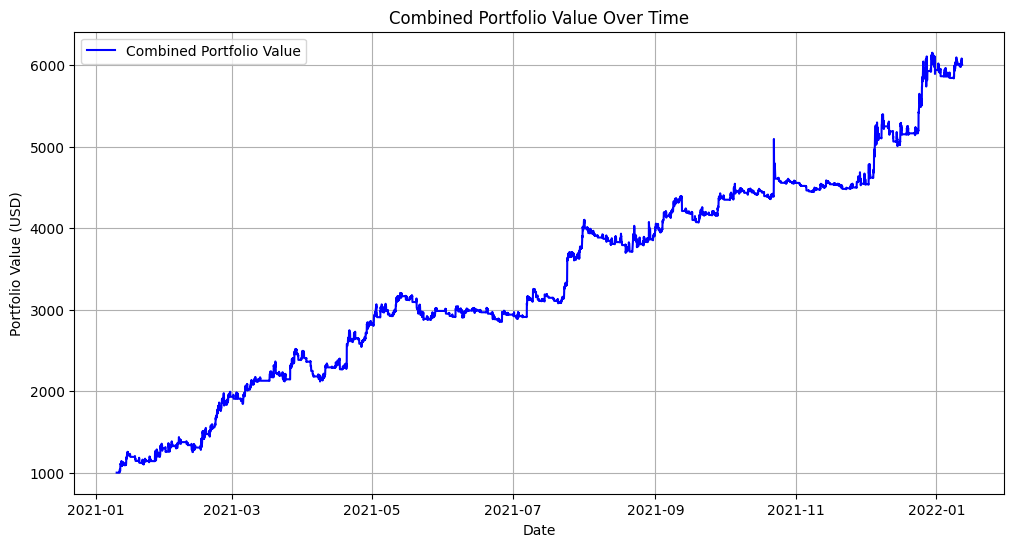

Final Combined Portfolio Value: $6009.43
Maximum Drawdown: 15.87%
Sortino Ratio: 0.0217
Sharpe Ratio: 0.0227


In [11]:
# Random Forest Classifier
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

data = pd.read_csv("/content/drive/MyDrive/InterIIT_2023-24/btcusdt_1h.csv")
data.head()

data.tail()

# Features construction
data['Open-Close'] = (data.open - data.close) / data.open
data['High-Low'] = (data.high - data.low) / data.low
data['percent_change'] = data['close'].pct_change()
data['std_5'] = data['percent_change'].rolling(5).std()
data['ret_5'] = data['percent_change'].rolling(5).mean()
data.dropna(inplace=True)

# X is the input variable
X = data[['Open-Close', 'High-Low', 'std_5', 'ret_5']]

# Y is the target or output variable
y = np.where(data['close'].shift(-1) > data['close'], 1, -1)

# Total dataset length
dataset_length = data.shape[0]

# Training dataset length
split = int(dataset_length * 0.75)
split

# Splitting the X and y into train and test datasets
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Print the size of the train and test dataset
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

# Create the model on train dataset
clf = RandomForestClassifier()  # Create a RandomForestClassifier instance

model = clf.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
print('Correct Prediction (%): ', accuracy_score(y_test, model.predict(X_test), normalize=True) * 100.0)

# Run the code to view the classification report metrics
from sklearn.metrics import classification_report
report = classification_report(y_test, model.predict(X_test))
print(report)

# Apply the strategy logic - Hold stock between -0.25% and 0.25%
data['Date'] = pd.to_datetime(data['datetime'])  # Convert the 'Date' column to datetime
data['strategy_returns'] = data.percent_change.shift(-1) * model.predict(X)

# Define the threshold values
lower_threshold = -0.001  # -0.25% as decimal
upper_threshold = 0.001   # 0.25% as decimal

# Apply the strategy logic
data['strategy_returns'] = np.where(
    (data['strategy_returns'] >= lower_threshold) & (data['strategy_returns'] <= upper_threshold),
    0,  # Hold stock
    data['strategy_returns']  # Proceed as usual
)

# Portfolio simulation
starting_capital = 1000  # Starting capital in USD
portfolio_value = [starting_capital]  # List to store portfolio value over time
# Define bitcoin_prices as the closing price from your data
bitcoin_prices = data['close']

# Initialize variables
current_cash = starting_capital
bitcoin_purchased = 0
portfolio_value = [starting_capital]

# Calculate SMA for a specific window size (e.g., 24 periods)
sma_window = 24
data['SMA'] = data['close'].rolling(sma_window).mean()

# Generate SMA signals (1 for buy, -1 for sell)
data['SMA_Signal'] = np.where(data['close'] > data['SMA'], 1, -1)



# Initialize variables for the combined strategy
current_cash = starting_capital
bitcoin_purchased = 0
portfolio_value_combined = [starting_capital]

# Initialize a list to store signals
signal_list = []

# Define the transaction cost as a percentage
transaction_cost_percentage = 0.001  # 0.1%





# Calculate the Z-score for the closing price
z_score_window = 24*20 # Choose a suitable window size
data['Z_Score'] = (data['close'] - data['close'].rolling(z_score_window).mean()) / data['close'].rolling(z_score_window).std()
# Define Z-score thresholds
buy_threshold = 2.50  # You can adjust this threshold
sell_threshold = -2.50  # You can adjust this threshold
# Generate Z-score signals (1 for buy, -1 for sell, 0 for hold)
data['Z_Score_Signal'] = np.where(data['Z_Score'] > buy_threshold, 1, np.where(data['Z_Score'] < sell_threshold, -1, 0))
# Combine signals from your existing strategy and the Z-score
data['Combined_Signal'] = (model.predict(X) + data['SMA_Signal'] + data['Z_Score_Signal']) / 3  # You can adjust the weights if needed





# Update the loop for portfolio simulation using the combined signal
for i in range(len(data['Combined_Signal'])):
    combined_signal = data['Combined_Signal'].iloc[i]
    current_price = bitcoin_prices.iloc[i]

    # Append the combined signal to the list
    signal_list.append(int(combined_signal))

    if combined_signal > 0:
        if current_cash > 5000 :
        # Buy Bitcoin with all available cash, considering transaction cost
          bitcoin_purchased += (5000 / current_price) * (1 - transaction_cost_percentage)
          current_cash -= 5000
        else :
          bitcoin_purchased += (current_cash / current_price) * (1 - transaction_cost_percentage)
          current_cash =0
    elif combined_signal < 0:
        # Sell all Bitcoin and add to cash, considering transaction cost
        current_cash += (bitcoin_purchased * current_price) * (1 - transaction_cost_percentage)
        bitcoin_purchased = 0



    # Calculate portfolio value at this time step
    portfolio_value_combined.append(current_cash + bitcoin_purchased * current_price)

# Print the first 20 elements of the signal list
print('First 20 Combined Signals:', signal_list[:20])

portfolio_length = len(data) - split
portfolio_value_combined_adjusted = portfolio_value_combined[:portfolio_length]

portfolio_data = data.iloc[split:].copy()
portfolio_data['Portfolio_Value'] = portfolio_value_combined_adjusted

# Plot the portfolio value over time for the combined strategy
plt.figure(figsize=(12, 6))
plt.plot(portfolio_data['Date'], portfolio_data['Portfolio_Value'], label='Combined Portfolio Value', color='blue')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.title('Combined Portfolio Value Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Print the final portfolio value for the combined strategy
final_portfolio_value_combined = portfolio_value_combined_adjusted[-1]
print('Final Combined Portfolio Value: ${:.2f}'.format(final_portfolio_value_combined))




# Calculate drawdown
portfolio_values = portfolio_data['Portfolio_Value']
peak_value = portfolio_values.cummax()
drawdown = -(portfolio_values - peak_value) / peak_value
max_drawdown = drawdown.max()

print('Maximum Drawdown: {:.2%}'.format(max_drawdown))

# Calculate average return, downside returns, and downside standard deviation for Sortino ratio
daily_returns = portfolio_values.pct_change()
average_return = daily_returns.mean()
downside_returns = daily_returns[daily_returns < 0]
downside_std_dev = downside_returns.std()

# Calculate daily risk-free rate from the annual rate (adjust as needed)
annual_risk_free_rate = 0.02  # Adjust to your desired annual risk-free rate
daily_risk_free_rate = (1 + annual_risk_free_rate) ** (1/252) - 1

# Calculate Sortino ratio with the appropriate daily risk-free rate
sortino_ratio = (average_return - daily_risk_free_rate) / downside_std_dev

print('Sortino Ratio: {:.4f}'.format(sortino_ratio))

# Calculate Sharpe ratio with the appropriate daily risk-free rate
sharpe_ratio = (average_return - daily_risk_free_rate) / daily_returns.std()

print('Sharpe Ratio: {:.4f}'.format(sharpe_ratio))





# Forced DrawDown

In [53]:
# Random Forest Classifier
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

data = pd.read_csv("/content/drive/MyDrive/InterIIT_2023-24/btcusdt_1h.csv")
data.head()

data.tail()

# Features construction
data['Open-Close'] = (data.open - data.close) / data.open
data['High-Low'] = (data.high - data.low) / data.low
data['percent_change'] = data['close'].pct_change()
data['std_5'] = data['percent_change'].rolling(5).std()
data['ret_5'] = data['percent_change'].rolling(5).mean()
data.dropna(inplace=True)

# X is the input variable
X = data[['Open-Close', 'High-Low', 'std_5', 'ret_5']]

# Y is the target or output variable
y = np.where(data['close'].shift(-1) > data['close'], 1, -1)

# Total dataset length
dataset_length = data.shape[0]

# Training dataset length
split = int(dataset_length * 0.75)
split

# Splitting the X and y into train and test datasets
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Print the size of the train and test dataset
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

# Create the model on train dataset
clf = RandomForestClassifier()  # Create a RandomForestClassifier instance

model = clf.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
print('Correct Prediction (%): ', accuracy_score(y_test, model.predict(X_test), normalize=True) * 100.0)

# Run the code to view the classification report metrics
from sklearn.metrics import classification_report
report = classification_report(y_test, model.predict(X_test))
print(report)

# Apply the strategy logic - Hold stock between -0.25% and 0.25%
data['Date'] = pd.to_datetime(data['datetime'])  # Convert the 'Date' column to datetime
data['strategy_returns'] = data.percent_change.shift(-1) * model.predict(X)

# Define the threshold values
lower_threshold = -0.001  # -0.25% as decimal
upper_threshold = 0.001   # 0.25% as decimal

# Apply the strategy logic
data['strategy_returns'] = np.where(
    (data['strategy_returns'] >= lower_threshold) & (data['strategy_returns'] <= upper_threshold),
    0,  # Hold stock
    data['strategy_returns']  # Proceed as usual
)

# Portfolio simulation
starting_capital = 1000  # Starting capital in USD
portfolio_value = [starting_capital]  # List to store portfolio value over time
# Define bitcoin_prices as the closing price from your data
bitcoin_prices = data['close']

# Initialize variables
current_cash = starting_capital
bitcoin_purchased = 0
portfolio_value = [starting_capital]

# Calculate SMA for a specific window size (e.g., 24 periods)
sma_window = 24
data['SMA'] = data['close'].rolling(sma_window).mean()

# Generate SMA signals (1 for buy, -1 for sell)
data['SMA_Signal'] = np.where(data['close'] > data['SMA'], 1, -1)



# Initialize variables for the combined strategy
current_cash = starting_capital
bitcoin_purchased = 0
portfolio_value_combined = [starting_capital]

# Initialize a list to store signals
signal_list = []

# Define the transaction cost as a percentage
transaction_cost_percentage = 0.001  # 0.1%





# Calculate the Z-score for the closing price
z_score_window = 24*20 # Choose a suitable window size
data['Z_Score'] = (data['close'] - data['close'].rolling(z_score_window).mean()) / data['close'].rolling(z_score_window).std()
# Define Z-score thresholds
buy_threshold = 2.50  # You can adjust this threshold
sell_threshold = -2.50  # You can adjust this threshold
# Generate Z-score signals (1 for buy, -1 for sell, 0 for hold)
data['Z_Score_Signal'] = np.where(data['Z_Score'] > buy_threshold, 1, np.where(data['Z_Score'] < sell_threshold, -1, 0))
# Combine signals from your existing strategy and the Z-score
data['Combined_Signal'] = (model.predict(X) + data['SMA_Signal'] + data['Z_Score_Signal']) / 3  # You can adjust the weights if needed



# Initialize portfolio_max to the initial portfolio value
portfolio_max = current_cash + bitcoin_purchased * current_price
curr_portfolio=0
curr_drawdown=0

# Update the loop for portfolio simulation using the combined signal
for i in range(len(data['Combined_Signal'])):
    combined_signal = data['Combined_Signal'].iloc[i]
    current_price = bitcoin_prices.iloc[i]



    # Append the combined signal to the list
    signal_list.append(int(combined_signal))
    current_cash_before_trade = current_cash
    bitcoin_purchased_before_trade = bitcoin_purchased
    current_price_before_trade = current_price

    if combined_signal > 0:
        if current_cash > 5000 :
        # Buy Bitcoin with all available cash, considering transaction cost
          bitcoin_purchased += (5000 / current_price) * (1 - transaction_cost_percentage)
          current_cash -= 5000
        else :
          bitcoin_purchased += (current_cash / current_price) * (1 - transaction_cost_percentage)
          current_cash =0
    elif combined_signal < 0:
        # Sell all Bitcoin and add to cash, considering transaction cost
        current_cash += (bitcoin_purchased * current_price) * (1 - transaction_cost_percentage)
        bitcoin_purchased = 0

    curr_portfolio = current_cash + bitcoin_purchased*current_price

    curr_drawdown = (portfolio_max - curr_portfolio)/portfolio_max

    if curr_drawdown > 0.08 :
        current_cash = current_cash_before_trade
        bitcoin_purchased = bitcoin_purchased_before_trade
        current_price = current_price_before_trade


    # Calculate portfolio value at this time step
    portfolio_value_combined.append(current_cash + bitcoin_purchased * current_price)
    if portfolio_max < portfolio_value_combined[-1] :
        portfolio_max = portfolio_value_combined




# Print the first 20 elements of the signal list
print('First 20 Combined Signals:', signal_list[:20])

portfolio_length = len(data) - split
portfolio_value_combined_adjusted = portfolio_value_combined[:portfolio_length]

portfolio_data = data.iloc[split:].copy()
portfolio_data['Portfolio_Value'] = portfolio_value_combined_adjusted

# Plot the portfolio value over time for the combined strategy
plt.figure(figsize=(12, 6))
plt.plot(portfolio_data['Date'], portfolio_data['Portfolio_Value'], label='Combined Portfolio Value', color='blue')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.title('Combined Portfolio Value Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Print the final portfolio value for the combined strategy
final_portfolio_value_combined = portfolio_value_combined_adjusted[-1]
print('Final Combined Portfolio Value: ${:.2f}'.format(final_portfolio_value_combined))




# Calculate drawdown
portfolio_values = portfolio_data['Portfolio_Value']
peak_value = portfolio_values.cummax()
drawdown = -(portfolio_values - peak_value) / peak_value
max_drawdown = drawdown.max()

print('Maximum Drawdown: {:.2%}'.format(max_drawdown))

# Calculate average return, downside returns, and downside standard deviation for Sortino ratio
daily_returns = portfolio_values.pct_change()
average_return = daily_returns.mean()
downside_returns = daily_returns[daily_returns < 0]
downside_std_dev = downside_returns.std()

# Calculate daily risk-free rate from the annual rate (adjust as needed)
annual_risk_free_rate = 0.02  # Adjust to your desired annual risk-free rate
daily_risk_free_rate = (1 + annual_risk_free_rate) ** (1/252) - 1

# Calculate Sortino ratio with the appropriate daily risk-free rate
sortino_ratio = (average_return - daily_risk_free_rate) / downside_std_dev

print('Sortino Ratio: {:.4f}'.format(sortino_ratio))

# Calculate Sharpe ratio with the appropriate daily risk-free rate
sharpe_ratio = (average_return - daily_risk_free_rate) / daily_returns.std()

print('Sharpe Ratio: {:.4f}'.format(sharpe_ratio))





(26402, 4) (8801, 4)
(26402,) (8801,)
Correct Prediction (%):  51.17600272696284
              precision    recall  f1-score   support

          -1       0.51      0.48      0.50      4377
           1       0.51      0.54      0.53      4424

    accuracy                           0.51      8801
   macro avg       0.51      0.51      0.51      8801
weighted avg       0.51      0.51      0.51      8801



ValueError: ignored

In [51]:
curr_drawdown

0.0